<h2 style="text-align: center;">НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ 
<br/>МОСКОВСКИЙ ЭНЕРГЕТИЧЕСКИЙ ИНСТИТУТ</h2>
</br>
<h3 style="text-align: center;">Кафедра Паровых и Газовых Турбин</h3>

</br>
</br>
</br>
</br>
</br>

<h1 style="text-align: center;">Курсовая работа по курсу:</h1>
<h1 style="text-align: center;">«Паровые и газовые турбины»</h1>

</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: right;">Студент: Смирнов Сергей Артёмович</h5>
<h5 style="text-align: right;">Группа: ФПэ-01-22</h5>

</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: center;">Москва 2025</h5>

## Вариант №1

### $\space$ Дано:
* $P_0 = 23.4 \space МПа $ - Давление перед турбиной
* $t_0 = 545 ^\circ C$ -  Температура перед турбиной
* $P_{пп} = 3.3 \space МПа$ -  Давление промперегрева
* $t_{пп} = 545 ^\circ C$ -  Температура промперегрева
* $P_{к} = 5 \space кПа$ -  Давление в конденсаторе
* $t_{п.в.} = 263^\circ C$ -  Температура питательной воды

* $N_{э} = 320 \space МВт$ -  Электрическая мощность
* z = 9 -  Количество перегревателей

# 1. Построение процесса расширения пара в турбине. Определение расходов пара на входе в турбину $G_0$ и в конденсатор $G_к$.

In [1]:
from G_2 import calc_mass_flow
from G_2 import r
from steam import Steam as my_steam

In [2]:
MPa = 10 ** 6
kPa = 10 ** 3
unit = 1 / MPa
to_kelvin = lambda x: x + 273.15 if x else None

In [3]:
p0 = 25 * MPa
G_calc = my_steam(name = "steam", R = 461, c_p =287.05)
A = calc_mass_flow(G_calc,
                   p0 = 23.4 * MPa ,
                   t0 = 545 ,
                   p_middle = 3.3 * MPa ,
                   t_middle = 545 ,
                   pk = 5 * kPa, 
                   t_feed_water = 263,
                   p_feed_water = 1.35 * p0,

                   electrical_power = 320*10**6,
                   internal_efficiency = 0.85,
                   mechanical_efficiency = 0.995,
                   generator_efficiency = 0.99,
                   alpha = 0.83)

inlet_mass_flow = A.inlet_mass_flow
condenser_mass_flow = A.condenser_mass_flow
print("Расход на входе в турбину: ",r(inlet_mass_flow), "кг /с")
print("Расход на входе в конденсатор: ",r(condenser_mass_flow), "кг/с")

Расход на входе в турбину:  260 кг /с
Расход на входе в конденсатор:  177 кг/с


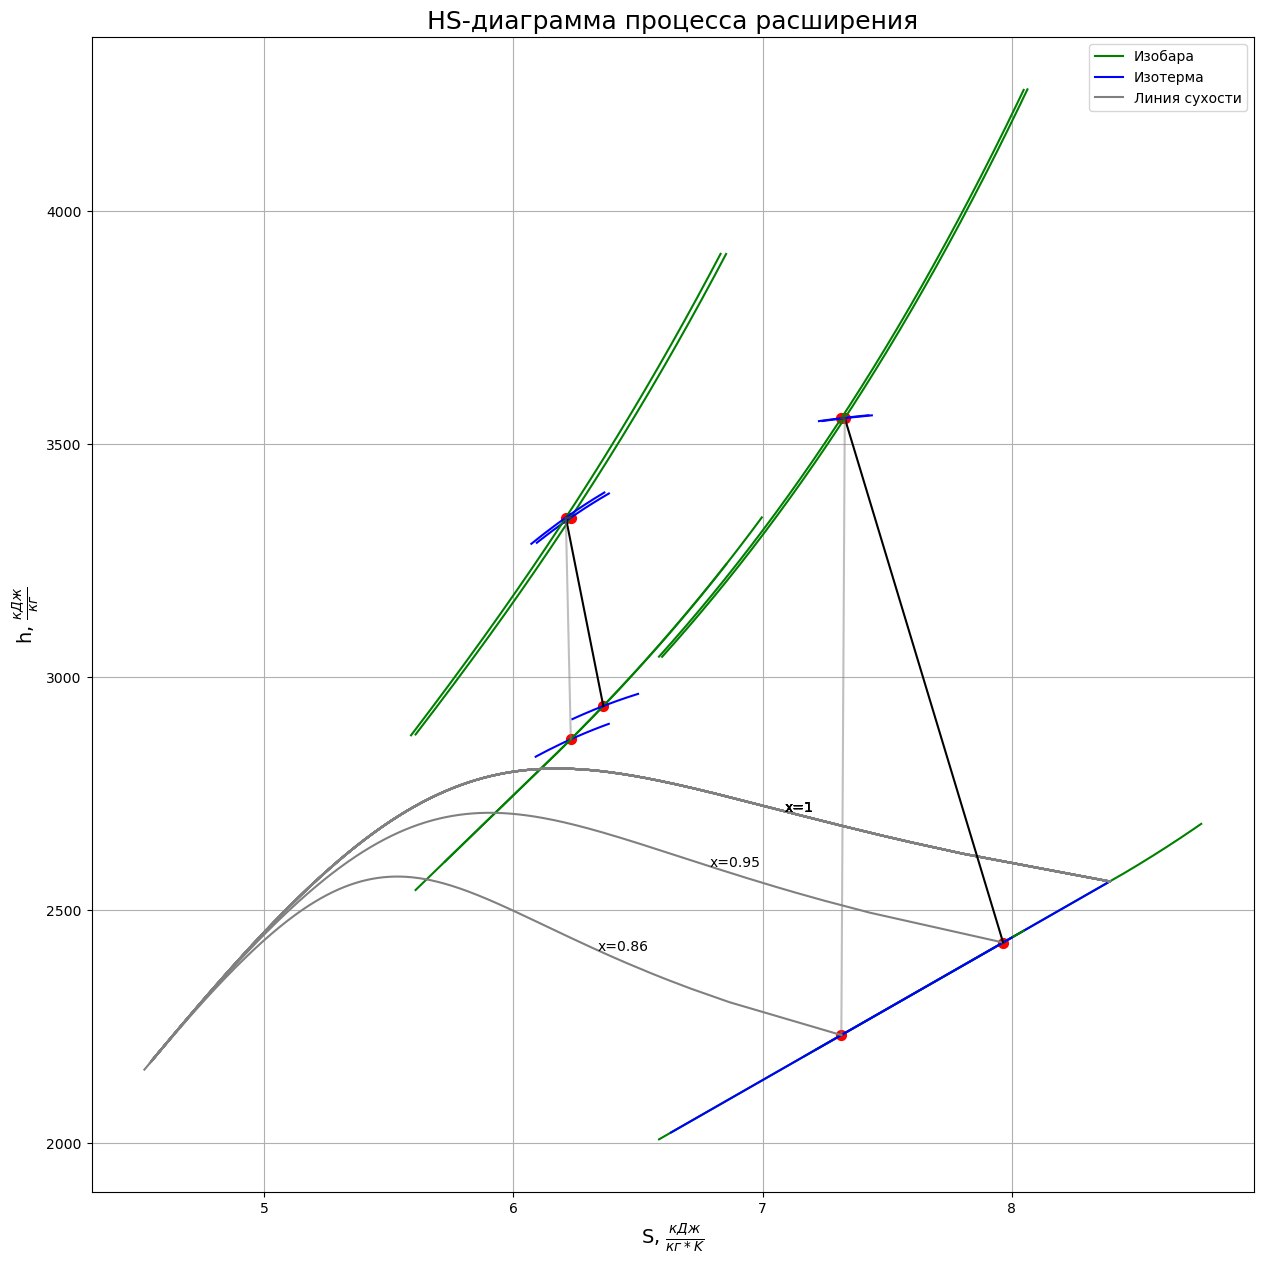

In [4]:
A.all_hs_plot

# Задание 2

Проведение расчёта регулирующей ступени и определние зависимости $\eta_{ол}$ от $U/c_f$. Диапазон варирьуемого параметра - диаметра - задан; обоснованно выбрать вариант исполнения регулирующей ступени для проектирования ЦВД в рамках заданного диапазона

Выберем в качестве сопловой лопатки *С-90-12А*, в качестве рабочей: *Р-26-17А*
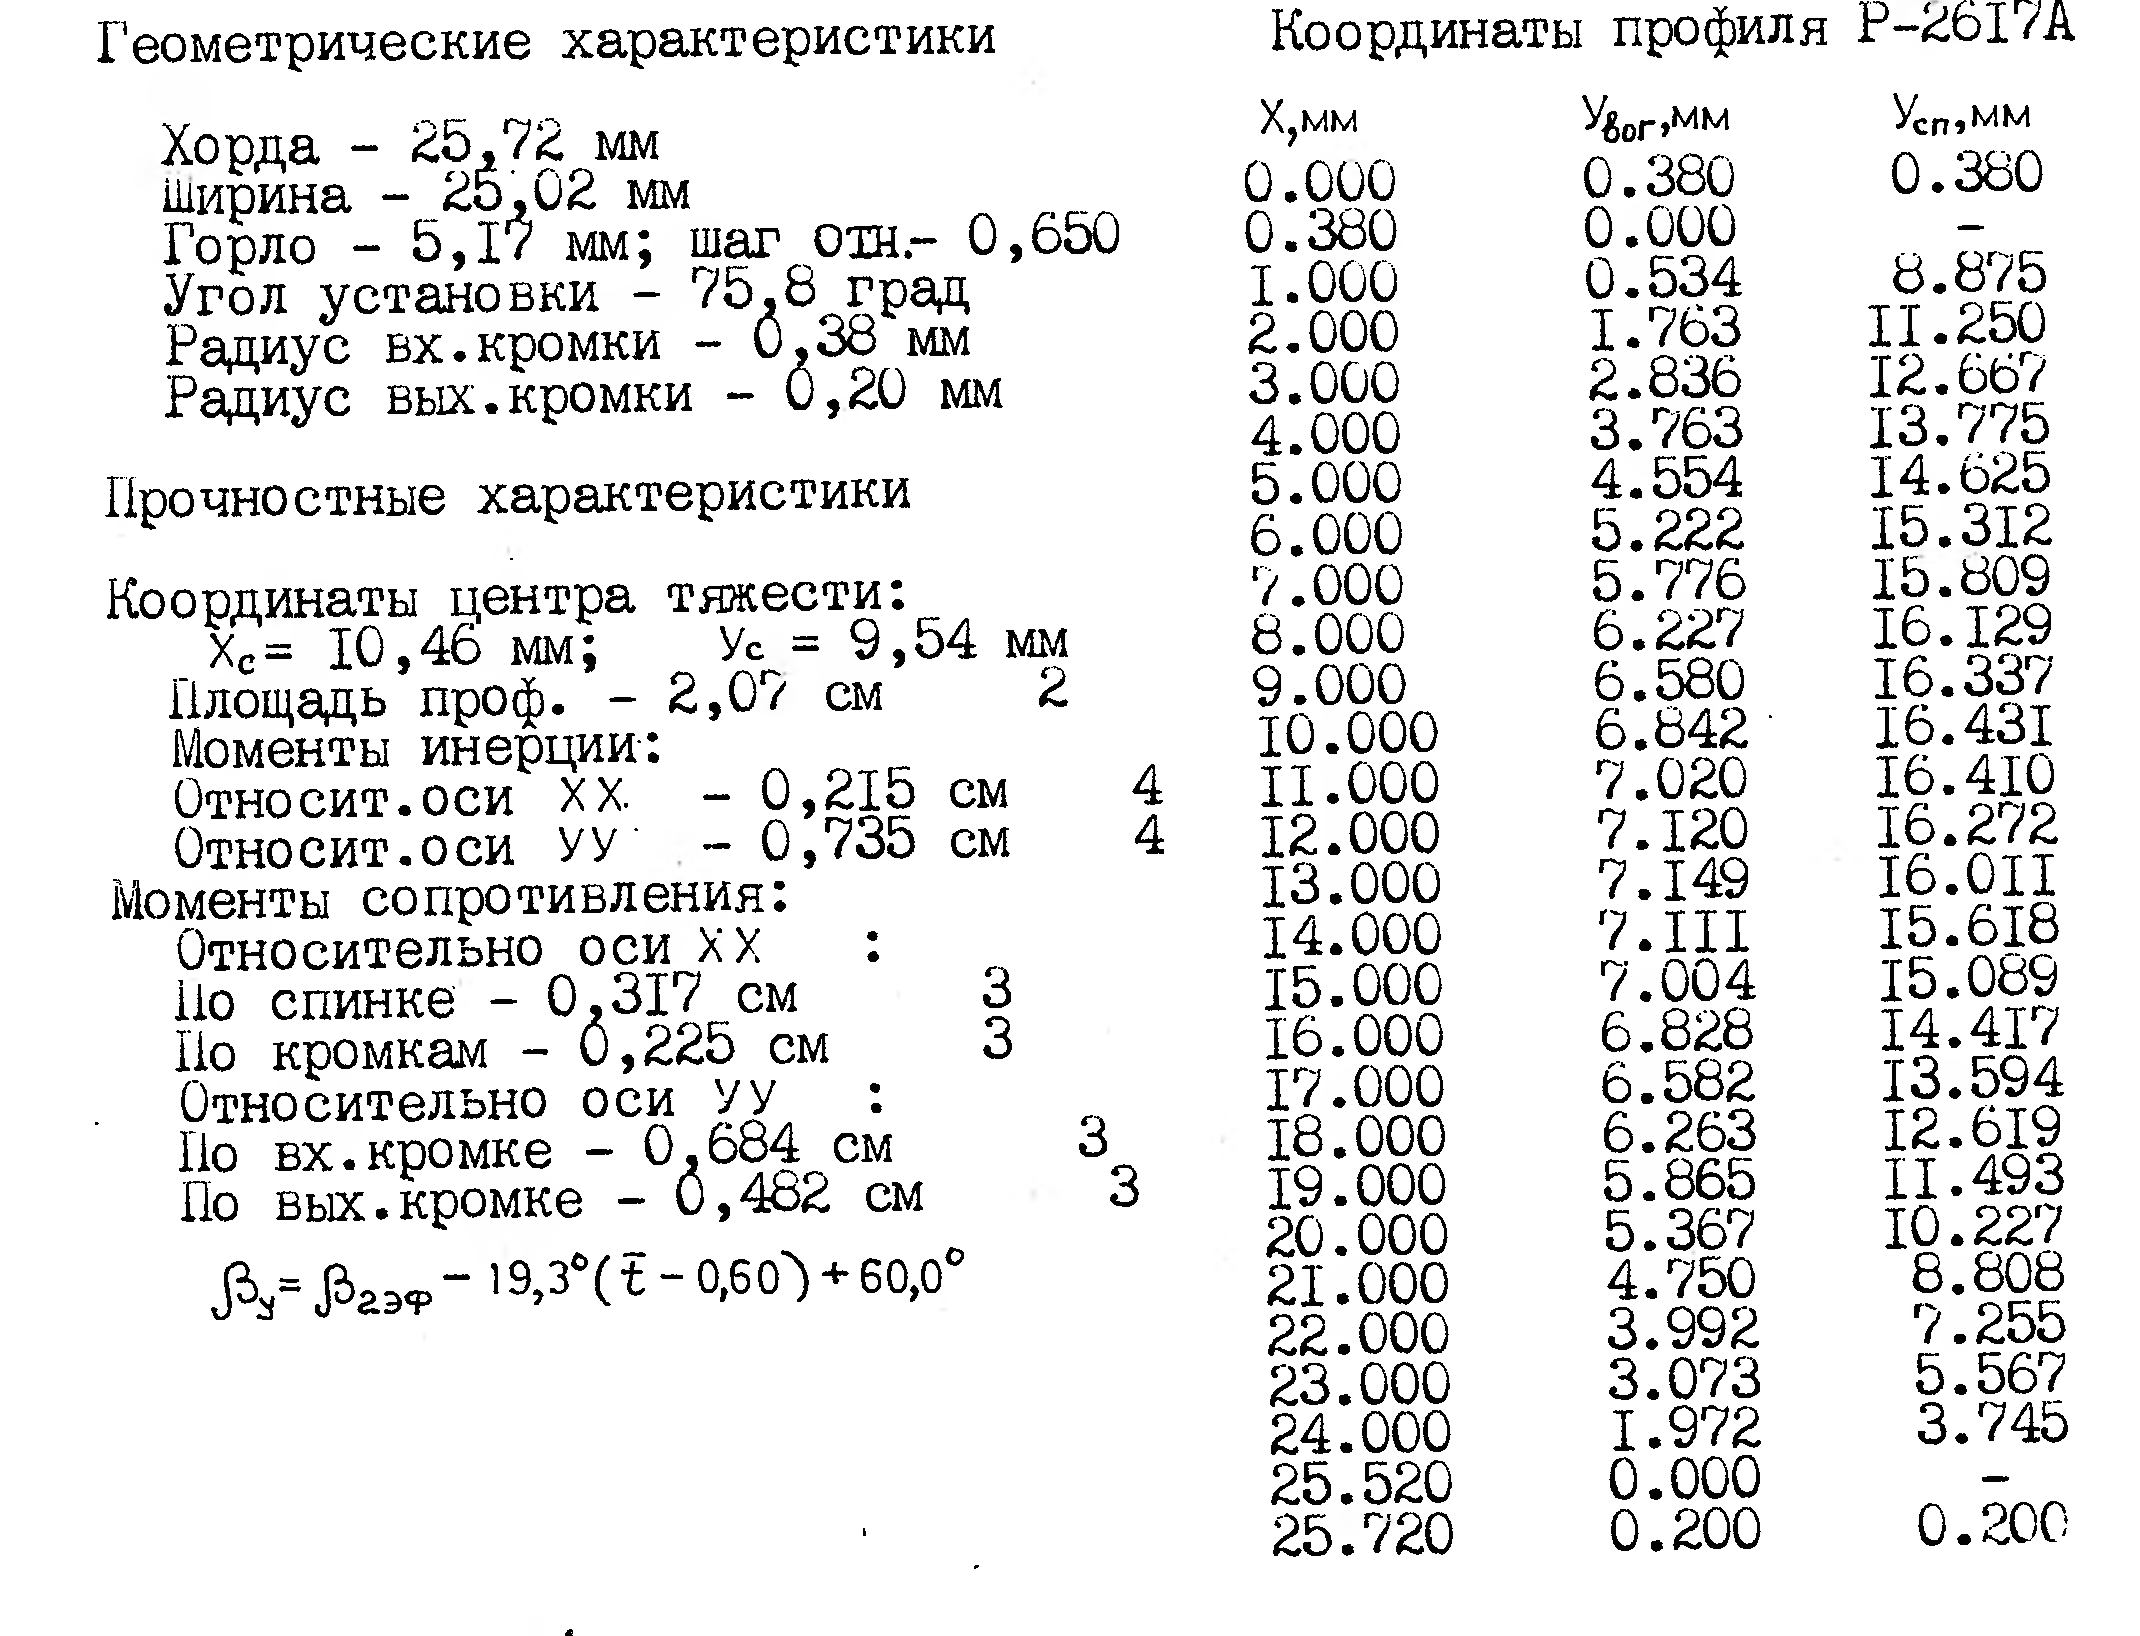

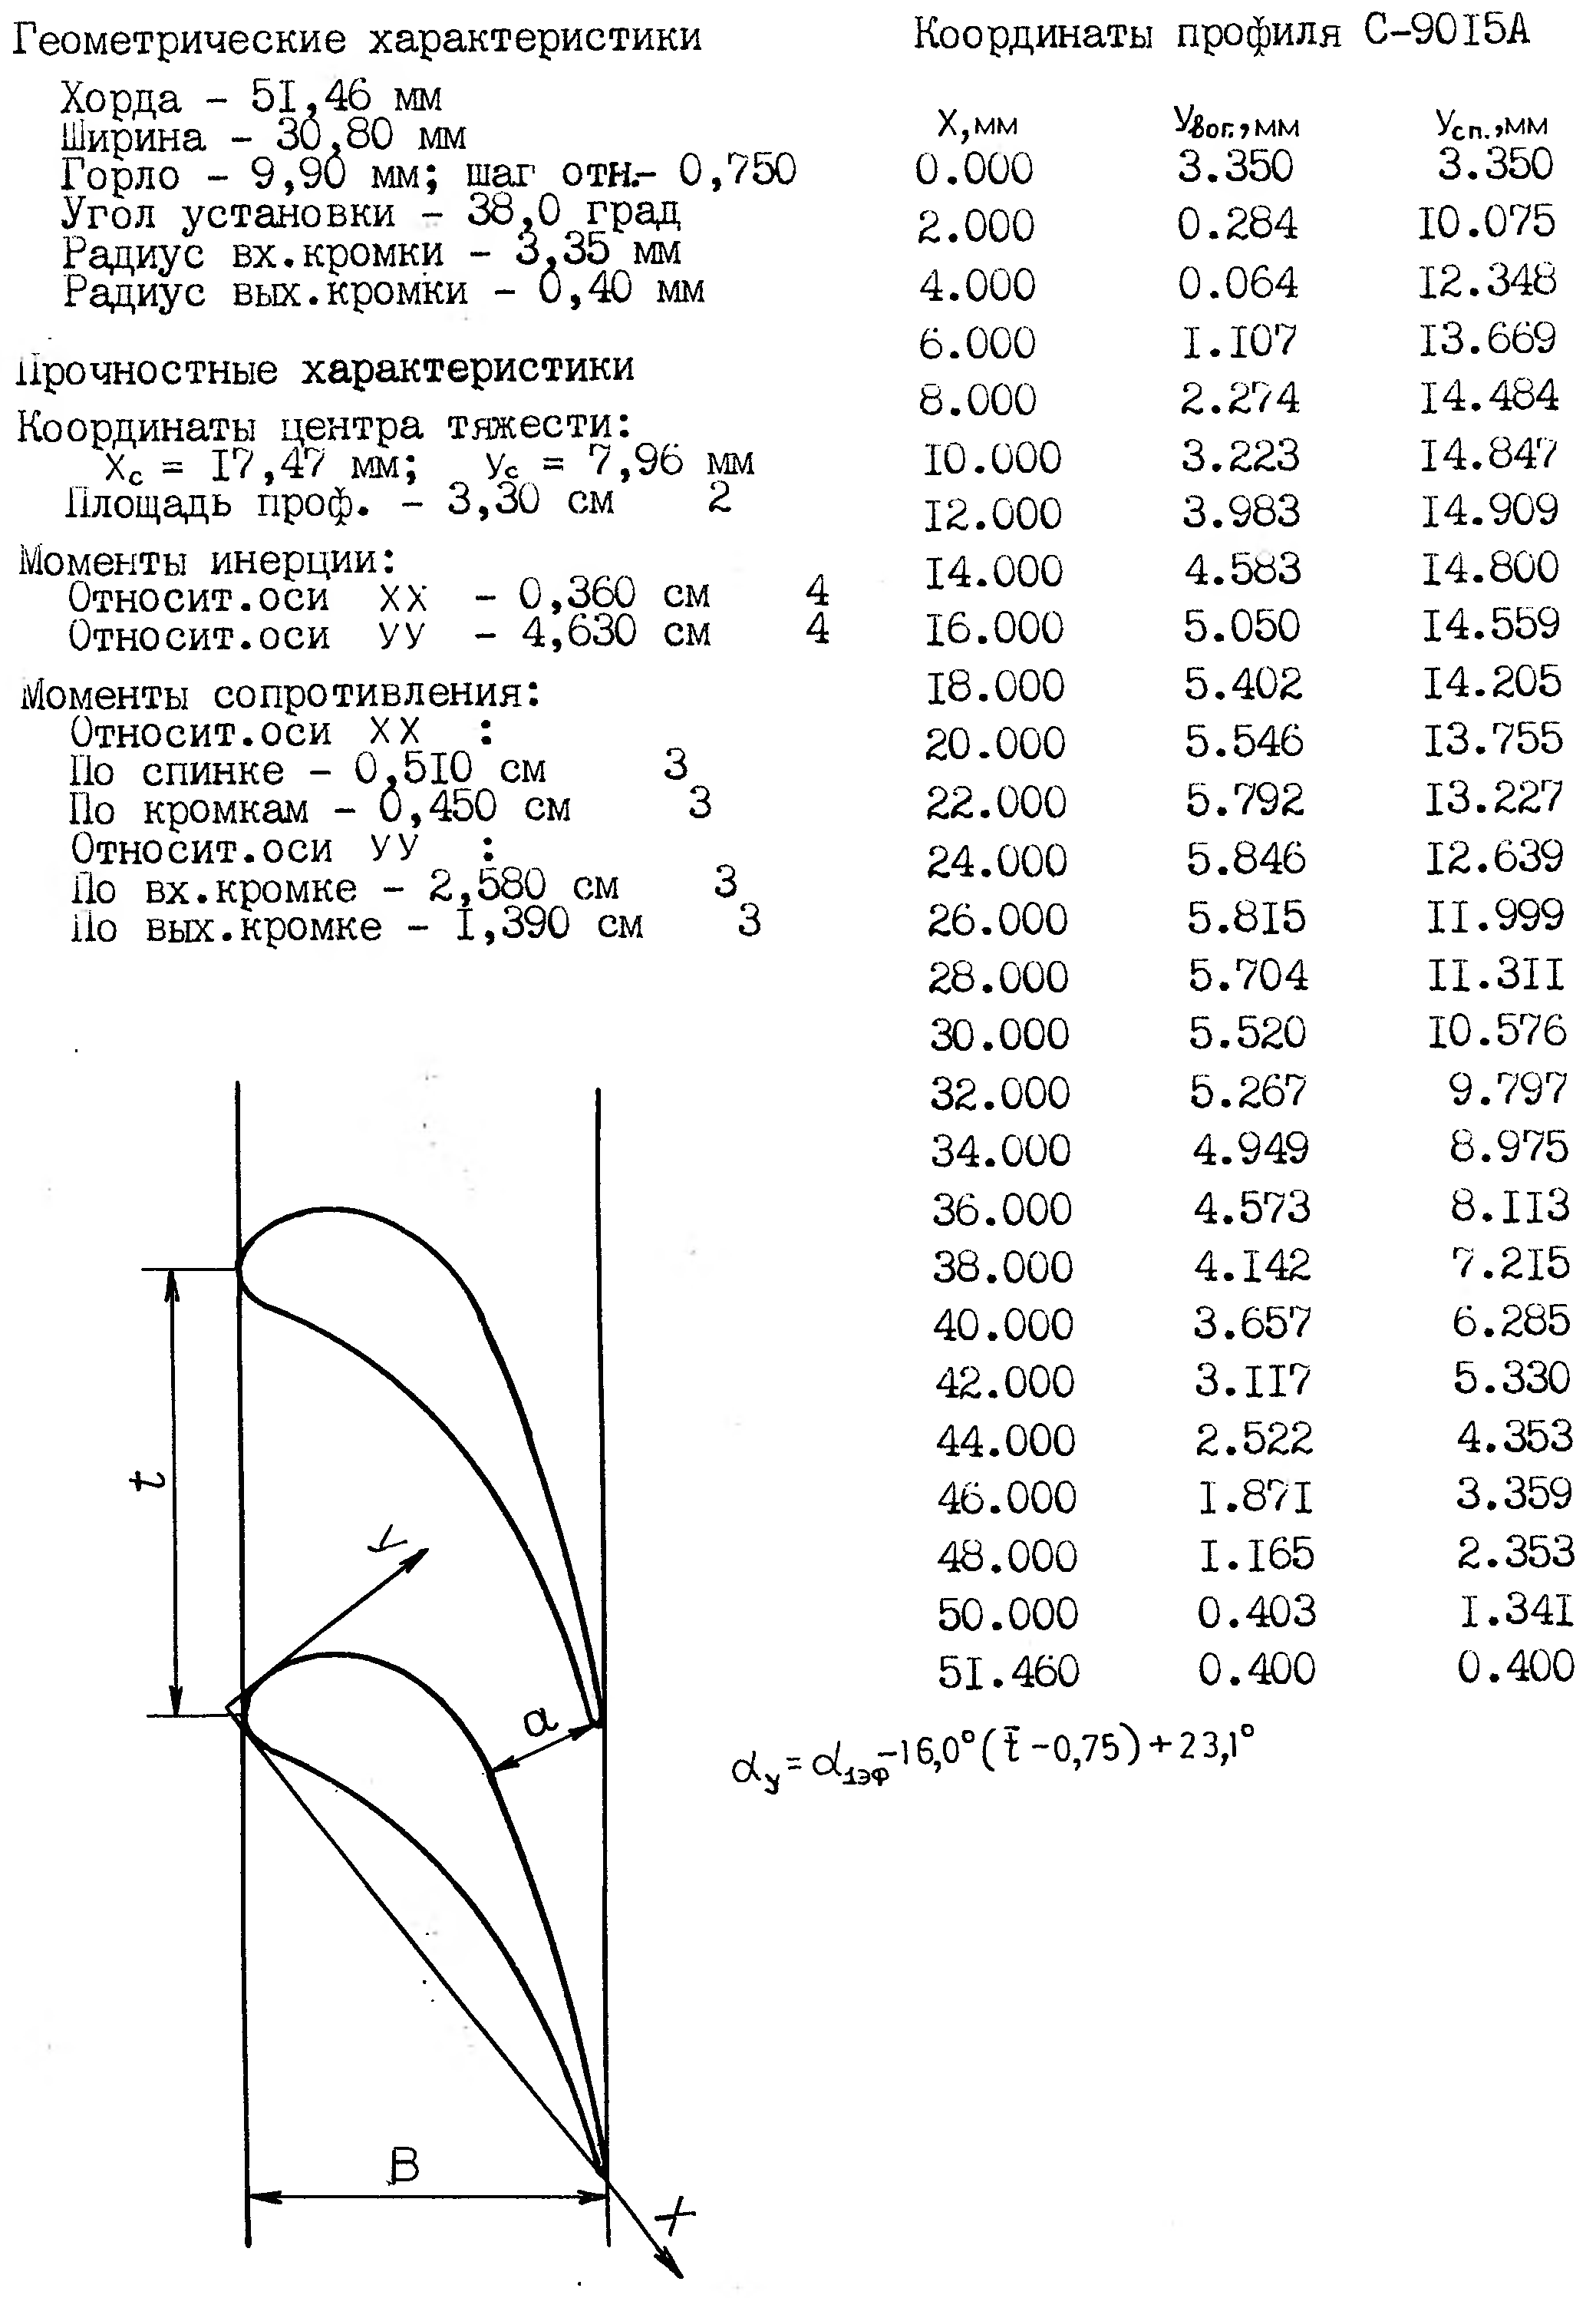

In [4]:
import numpy as np
import matplotlib.pyplot as plt
H_o = 100
k = 1.33
n = 60
rho = 0.1
b_1 = 51.5
d =0.9
p0 = 23.4 * MPa
t0 = 545
alpha_1_e = 15
t_1opt = (0.7+0.87)/2
t_opt_2 = (0.60+0.70)/2
b_2 = 25.7
G = inlet_mass_flow# = 257.13
pere = 0.003
xi_vs = 0
d_r = np.arange(0.9,1.1,0.01) 
W_min_atlas = 0.575
# for i in range (9000, 11001, 1):
    # d_r.append(i*0.0001)

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Vait_\AppData\Local\Temp\ipykernel_29192\3675938710.py:21: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel(f"$\eta$, %")
C:\Users\Vait_\AppData\Local\Temp\ipykernel_2

Centrifugal stress: 15.01 MPa; Bending stress: 22.09 MPa; Final rotor height: 25.70 mm


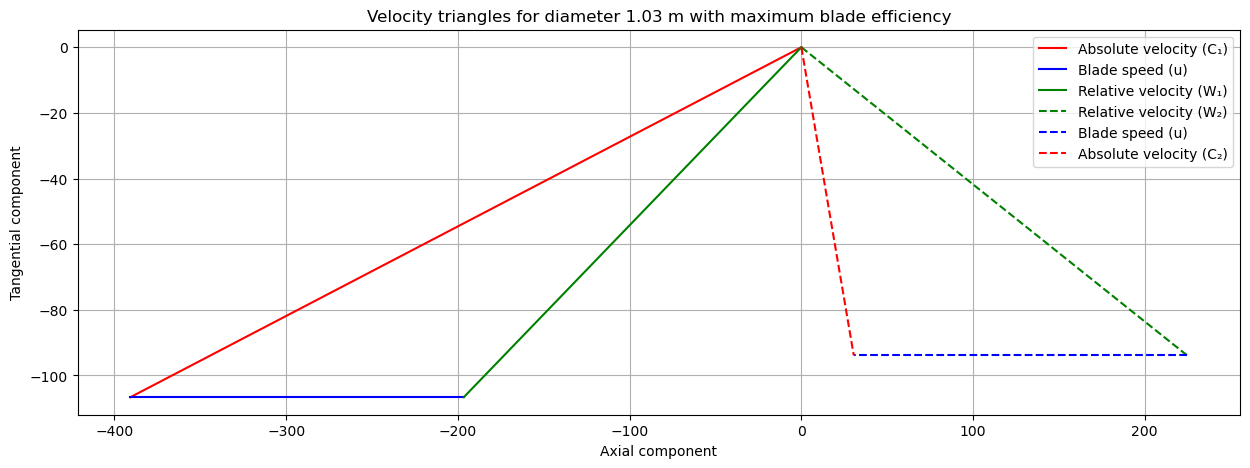

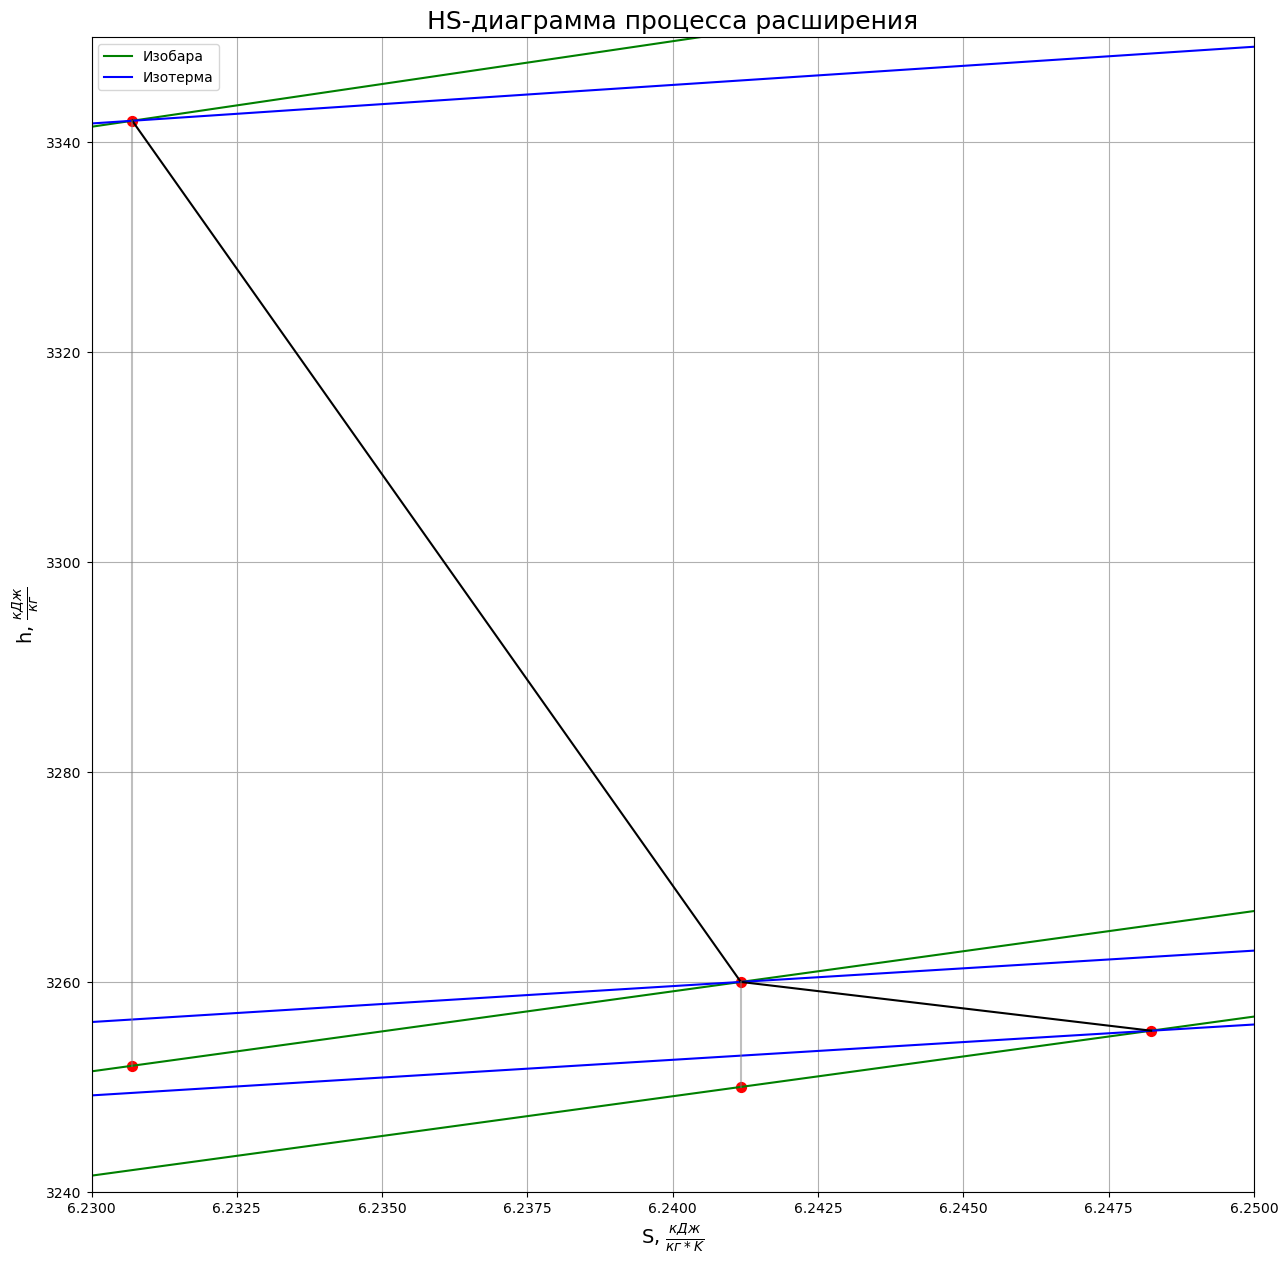

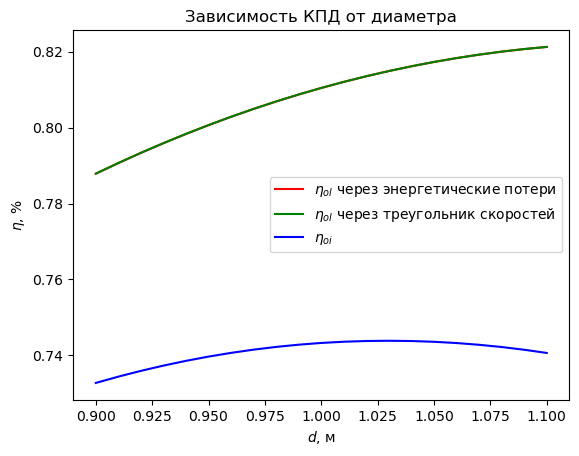

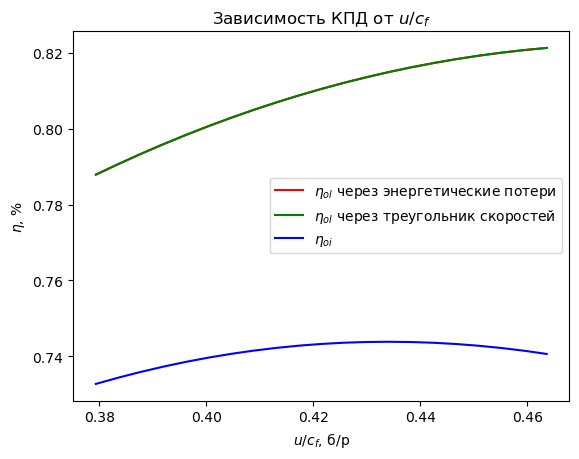

In [5]:
_eff_ol_energy = []
_eff_ol_angle = []
_eff_oi = []
_u_cf = []
for i in range(len(d_r)):
    eff_ol_energy, eff_ol_angle, eff_oi, u_cf, velocity_df, loss_df, thermodynamic_df = A.efficiency_oi_ol (H_o, p0,t0, k, n, rho, b_1, alpha_1_e, t_1opt, t_opt_2, b_2, G, pere, xi_vs, d_r[i], W_min_atlas)
    _eff_ol_energy.append(eff_ol_energy)
    _eff_ol_angle.append(eff_ol_angle)
    _eff_oi.append(eff_oi)
    _u_cf.append(u_cf)

# fig, ax = plt.subplots(1, 1, figsize=(15,5))
# ax.plot(range(d_r, _eff_ol_energy, legend = "")
# ax.plot(range(d_r, _eff_ol_energy)

# ax.set_xlabel("Номер ступени")
# ax.set_ylabel(ax_name)
# ax.grid()
plt.title("Зависимость КПД от диаметра") 
plt.xlabel(f"$d$, м") 
plt.ylabel(f"$\eta$, %")     
plt.plot(d_r,_eff_ol_energy , color ="red", label = "$\eta_{ol}$ через энергетические потери")
plt.plot(d_r,_eff_ol_angle, color ="green",label = "$\eta_{ol}$ через треугольник скоростей")
plt.plot(d_r,_eff_oi, color ="blue", label = "$\eta_{oi}$")
plt.legend()
plt.show()

plt.title("Зависимость КПД от $u/c_f$") 
plt.xlabel(f"$u/c_f$, б/р") 
plt.ylabel(f"$\eta$, %")     
plt.plot(_u_cf,_eff_ol_energy , color ="red", label = "$\eta_{ol}$ через энергетические потери")
plt.plot(_u_cf,_eff_ol_angle, color ="green",label = "$\eta_{ol}$ через треугольник скоростей")
plt.plot(_u_cf,_eff_oi, color ="blue", label = "$\eta_{oi}$")
plt.legend()
plt.show()

In [6]:
velocity_df

,"Абсолютная скорость (с), м/с","Абсолютный угол (α), °","Относительная скорость (w), м/с","Относительный угол (β), °"
Локация,,,,
За сопловой решеткой,404.684,15.269,211.818,30.209
За рабочей решеткой,97.254,86.643,234.120,24.500


In [7]:
loss_df

,"Потери, %"
Тип потерь,
В сопловой решетке,8.115
В рабочей решетке,5.027
Энергия выходной скорости,4.729
Потери от утечек через уплотнение,4.371
Потери от трения диска,0.743
Потери от парциальности,2.953


In [8]:
thermodynamic_df

,"Давление (P), МПа","Температура (T), K","Энтальпия (h), кДж/кг","Энтропия (s), кДж/(кг·K)"
Состояние,,,,
Параметры перед ступенью,22.230,540.605,3342.009,6.231
Теоретические параметры за сопловой решеткой,16.608,487.876,3252.009,6.231
Фактические параметры за сопловой решеткой,16.608,490.507,3260.125,6.241
Теоретические параметры за ступенью,16.062,484.653,3250.125,6.241
Фактические параметры за ступенью,16.062,486.293,3255.152,6.248


Как видно из значений напряжений, изгибные напряжения находятся в норме (19.31 MPa < 20 MPa), значит, лопатка выдерживает прилагаемые напряжения и геометрия выбрана верно

# Задание 3

## Разбивка по ступеням

Ошибка определения веерности:  5.061257609858441 %'
Ошибка определения веерности:  0.17208871983742566 %'
Новое число ступеней:  9.544884316688483
Ошибка определения веерности:  0.17208871983742566 %'
Новое число ступеней:  9.553491412453022


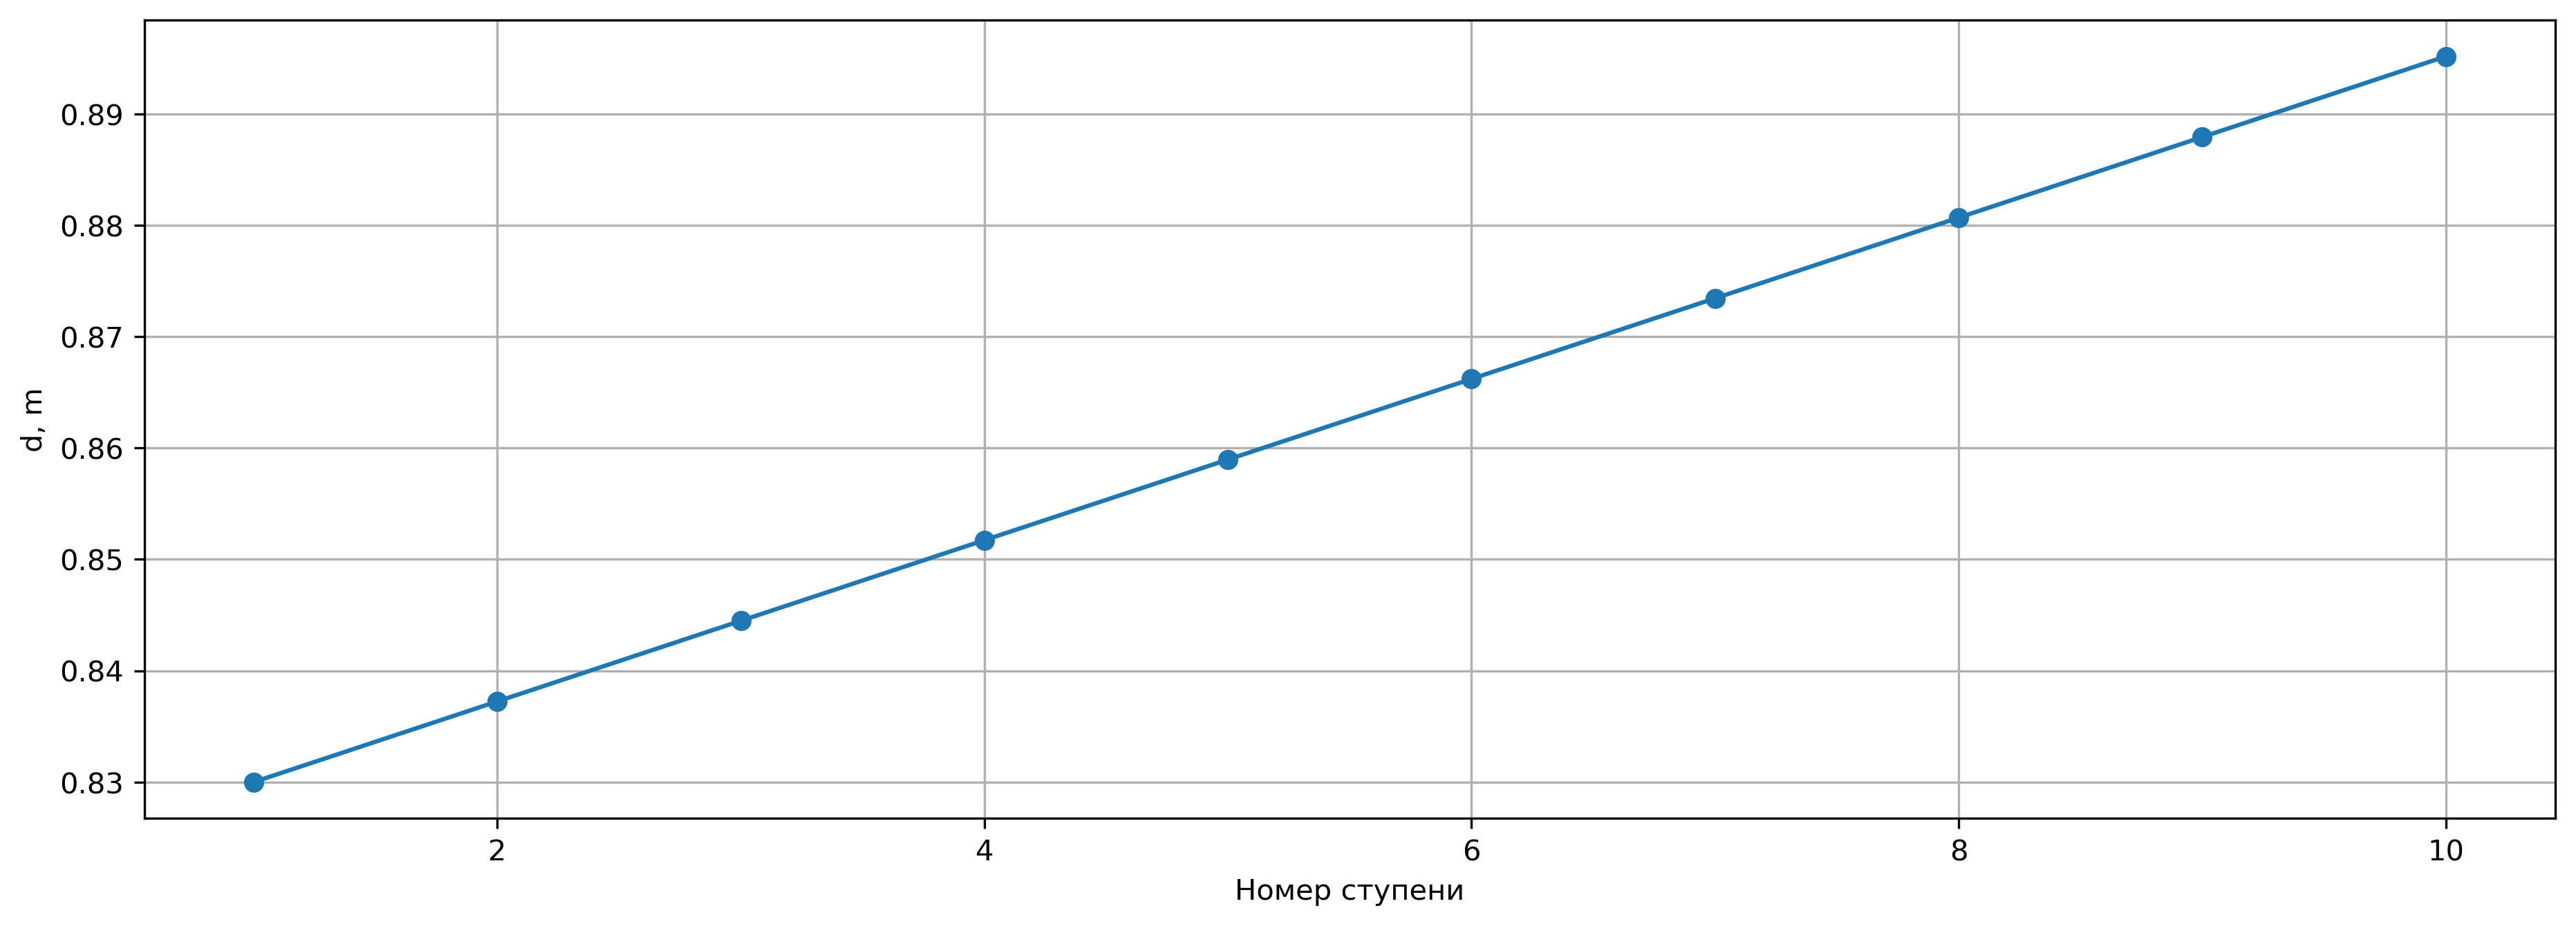

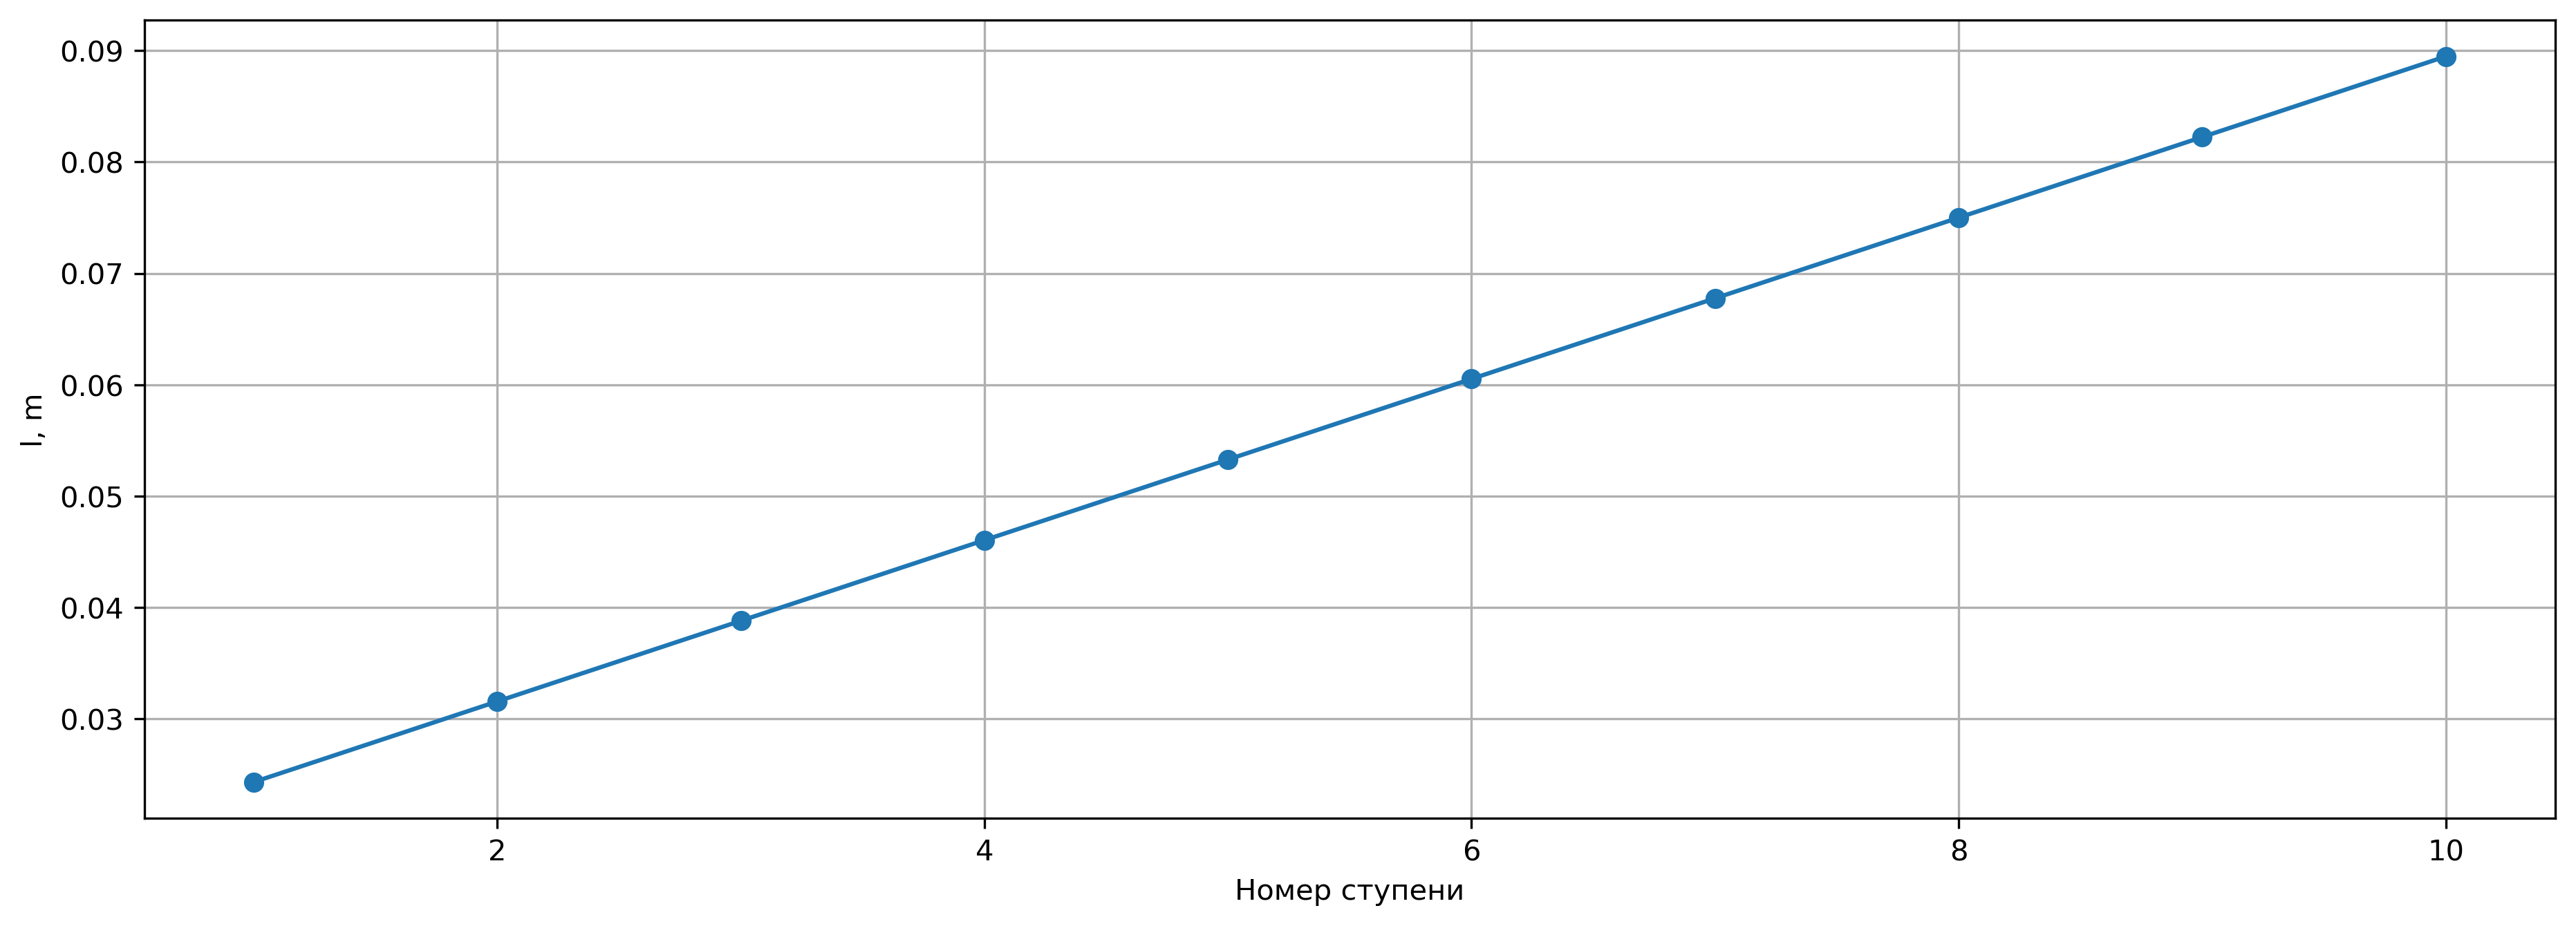

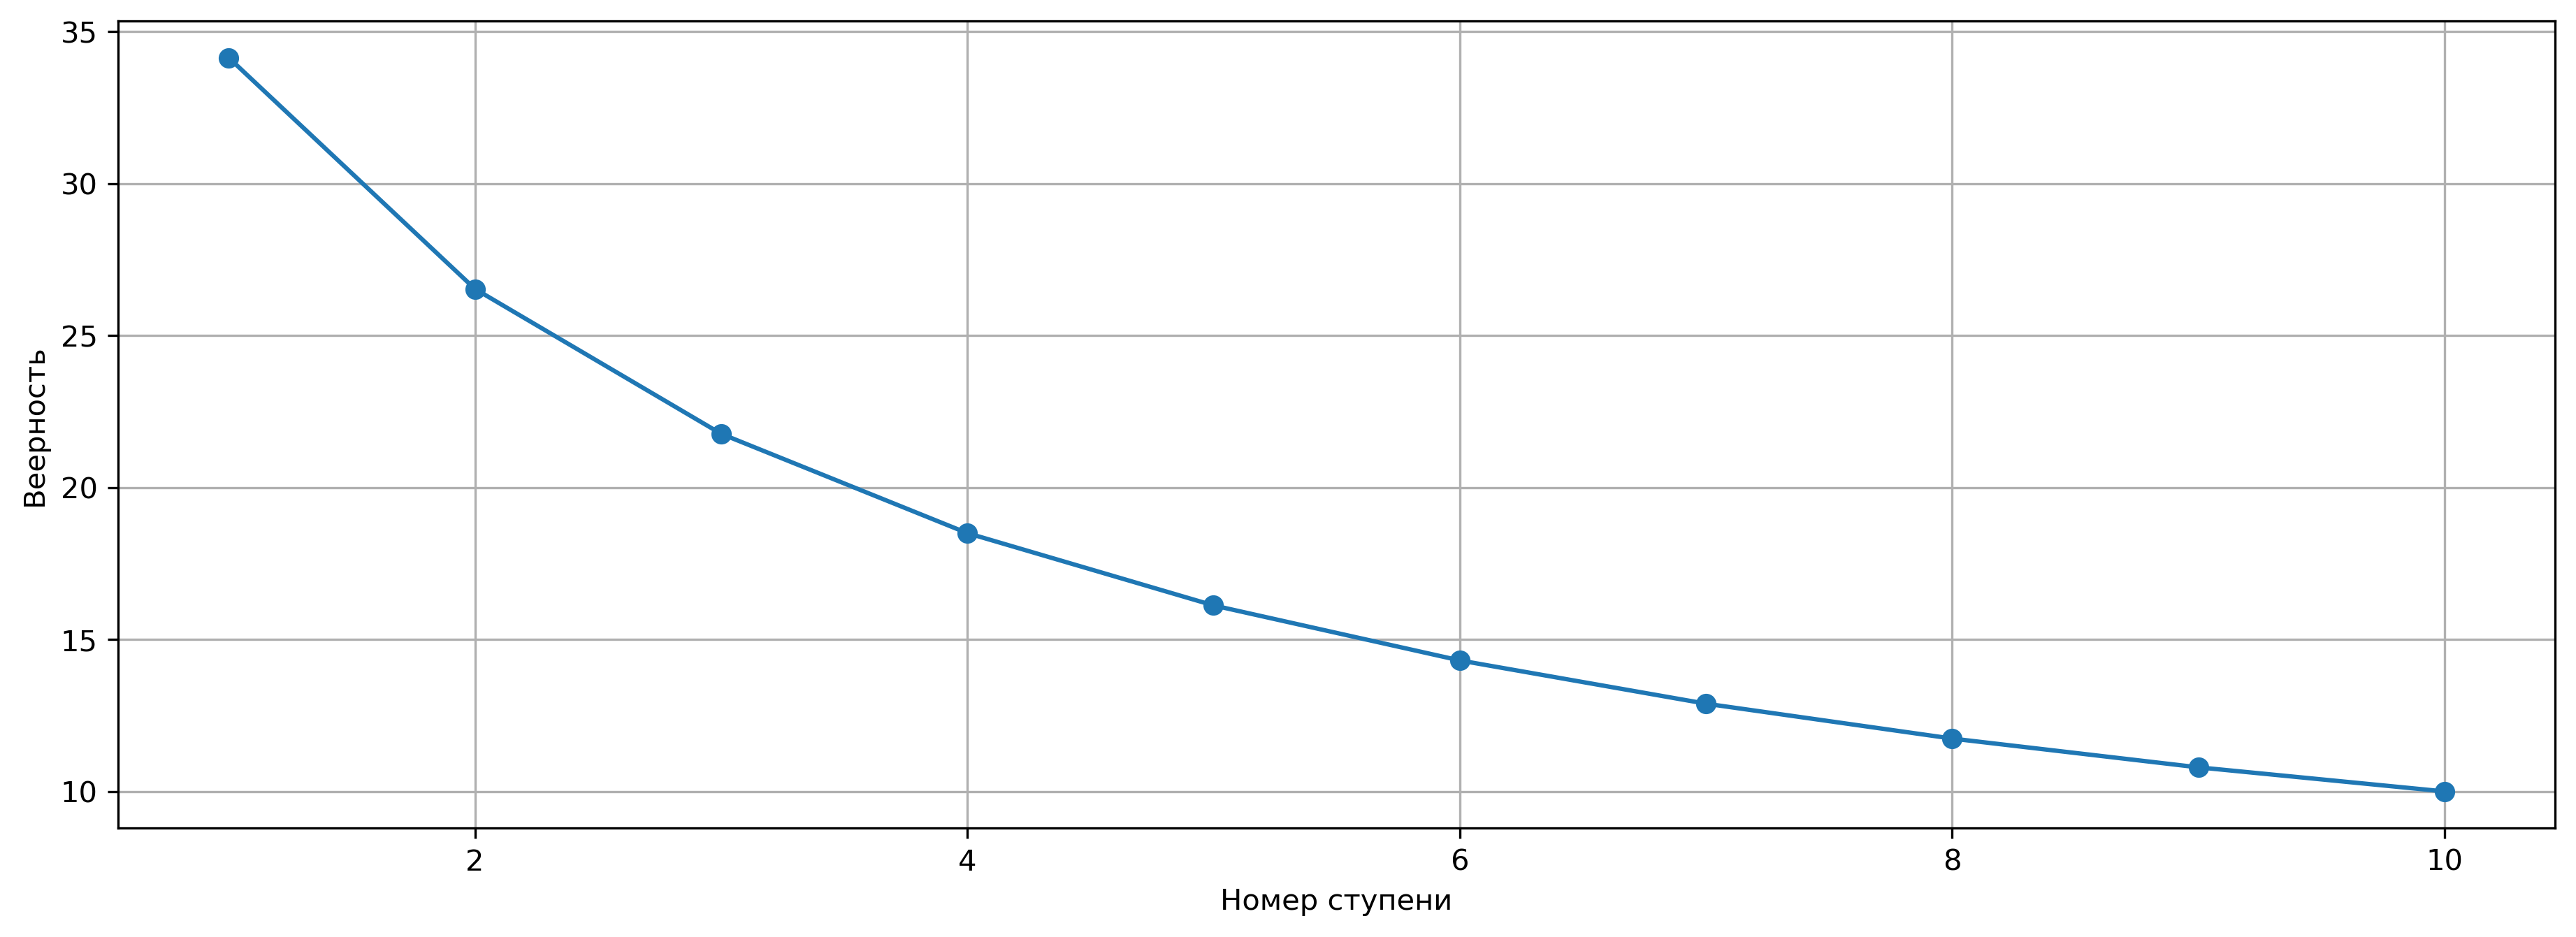

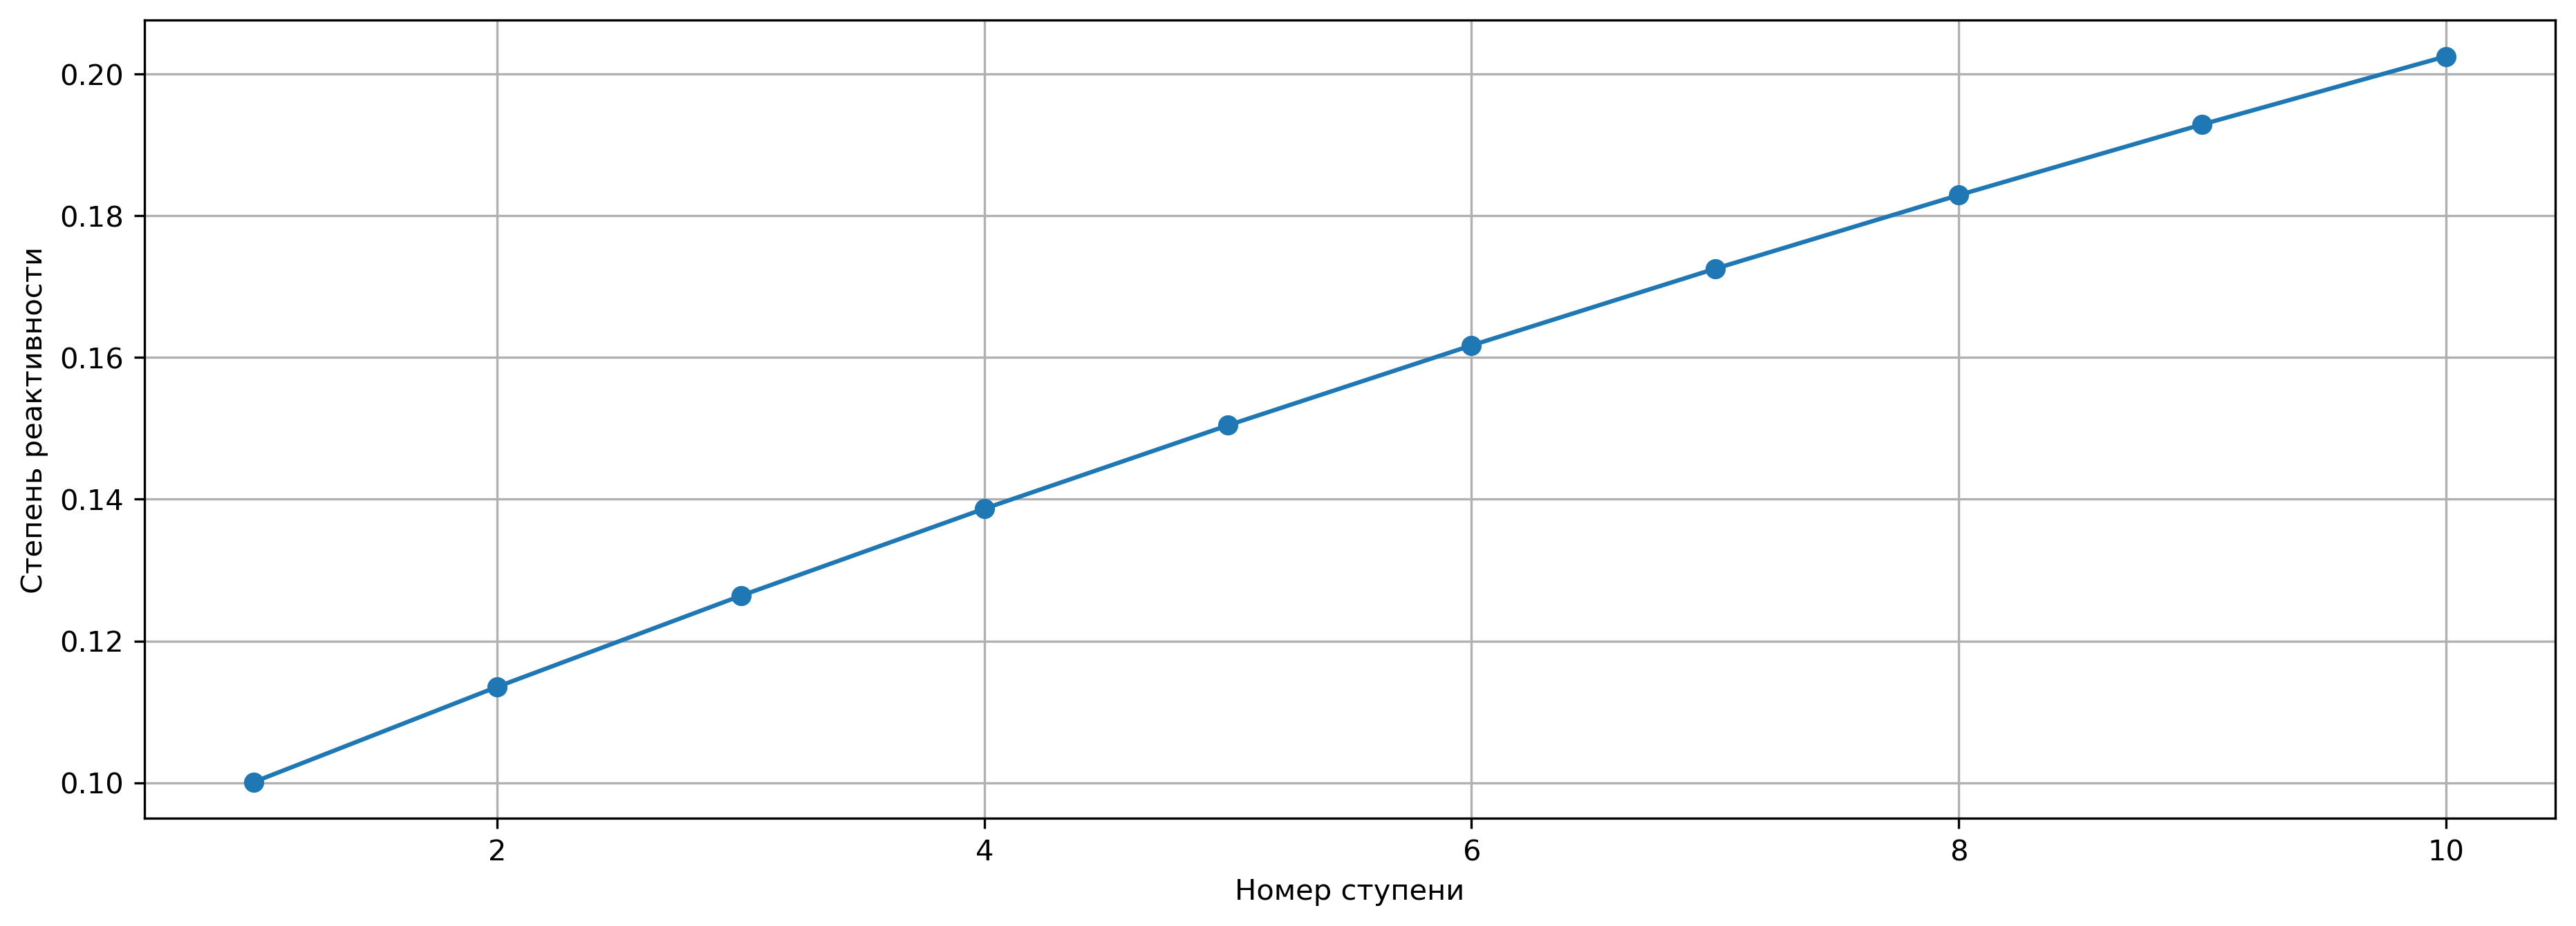

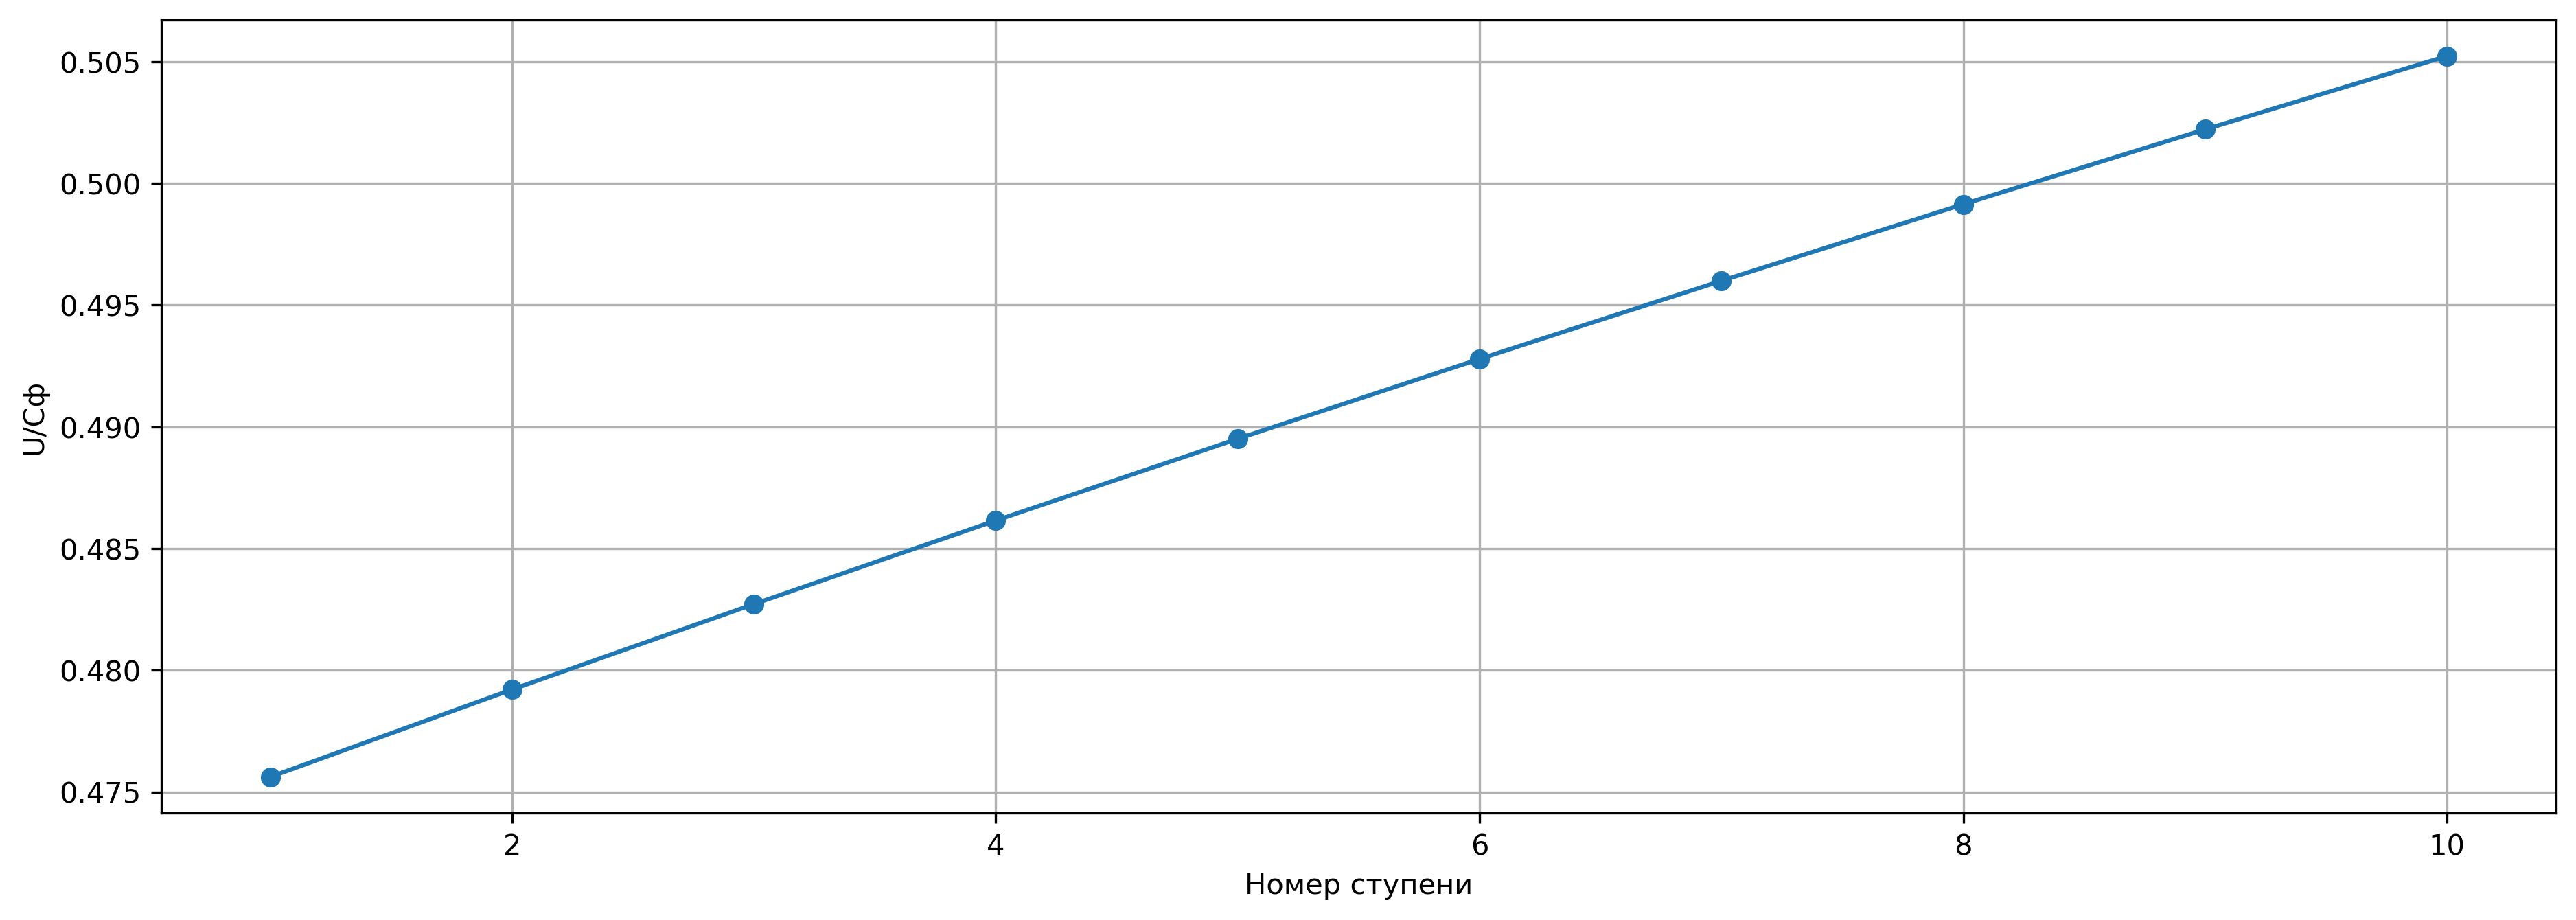

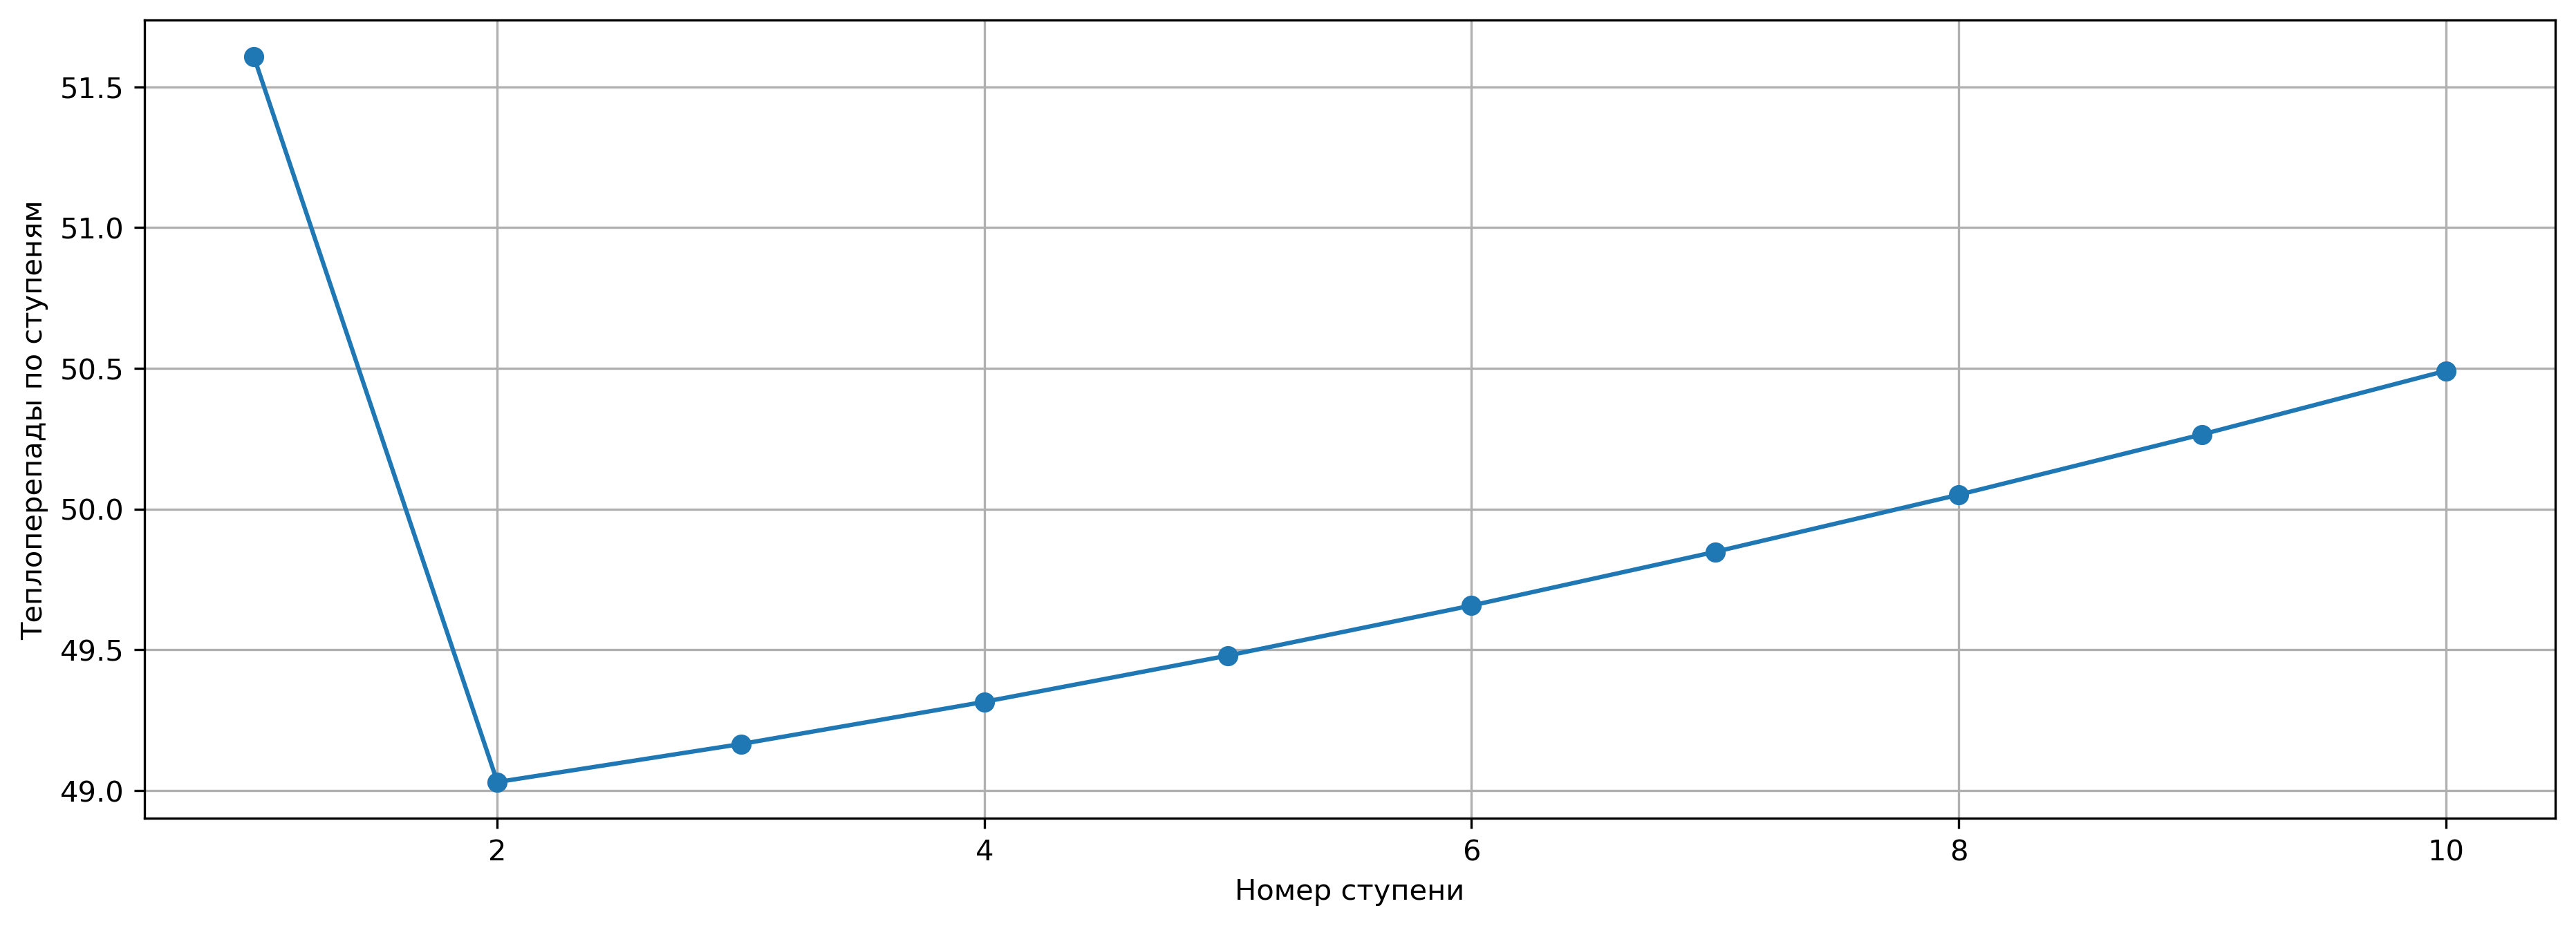

In [9]:
speed_stage_diam = d_r[np.argmax(_eff_oi)]
rotation_speed = n
n_stages = 9
mass_flow = inlet_mass_flow 
p0, h0, pz = A.get_point_z
p0 = p0 * MPa
# h0 = 3276.79 # kJ/kg
pz = pz * MPa


# Techincal params
delta_diam = 0.2
speed_coefficient = 0.93
alpha_1 = 14
root_reaction_degree = 0.05
discharge_coefficient = 0.96
overlapping = 0.003
efficiency = 0.88
veernost_1 = 37
my_blade_No = 8
diameter_my, blade_length_my, veernost_my, reaction_degree_my, u_cf_my, new_actual_heat_drop_my, p_in, T_in, h_in = A.each_blade(speed_stage_diam, 
                                                                                                               rotation_speed, 
                                                                                                               n_stages, 
                                                                                                               mass_flow, p0, h0, 
                                                                                                               pz, delta_diam, 
                                                                                                               speed_coefficient, 
                                                                                                               alpha_1, 
                                                                                                               root_reaction_degree, 
                                                                                                               discharge_coefficient, 
                                                                                                               overlapping, 
                                                                                                               efficiency, 
                                                                                                               veernost_1, 
                                                                                                               my_blade_No)

## Расчёт ступени №8

Centrifugal stress: 38.08 MPa; Bending stress: 28.29 MPa; Final rotor height: 20.00 mm


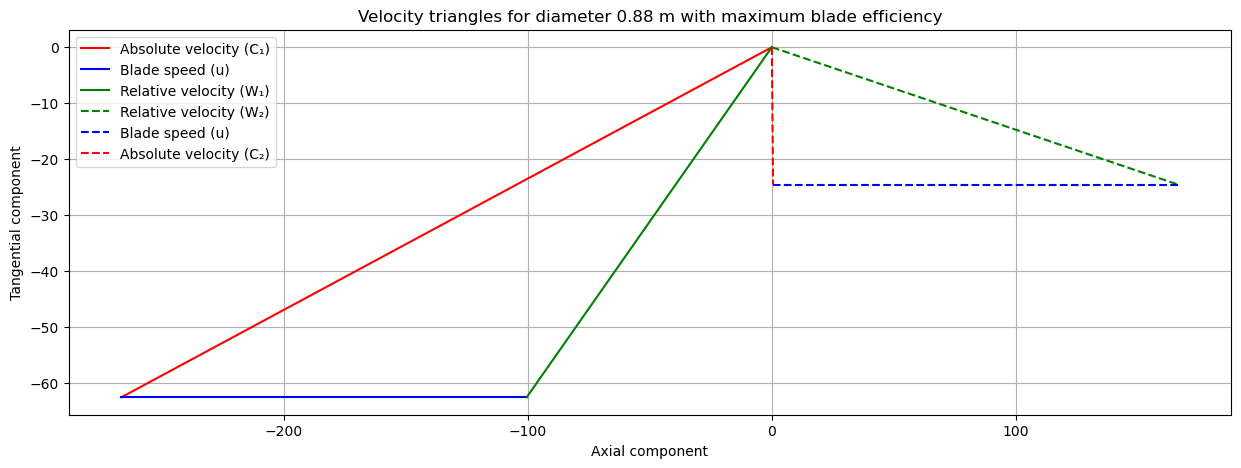

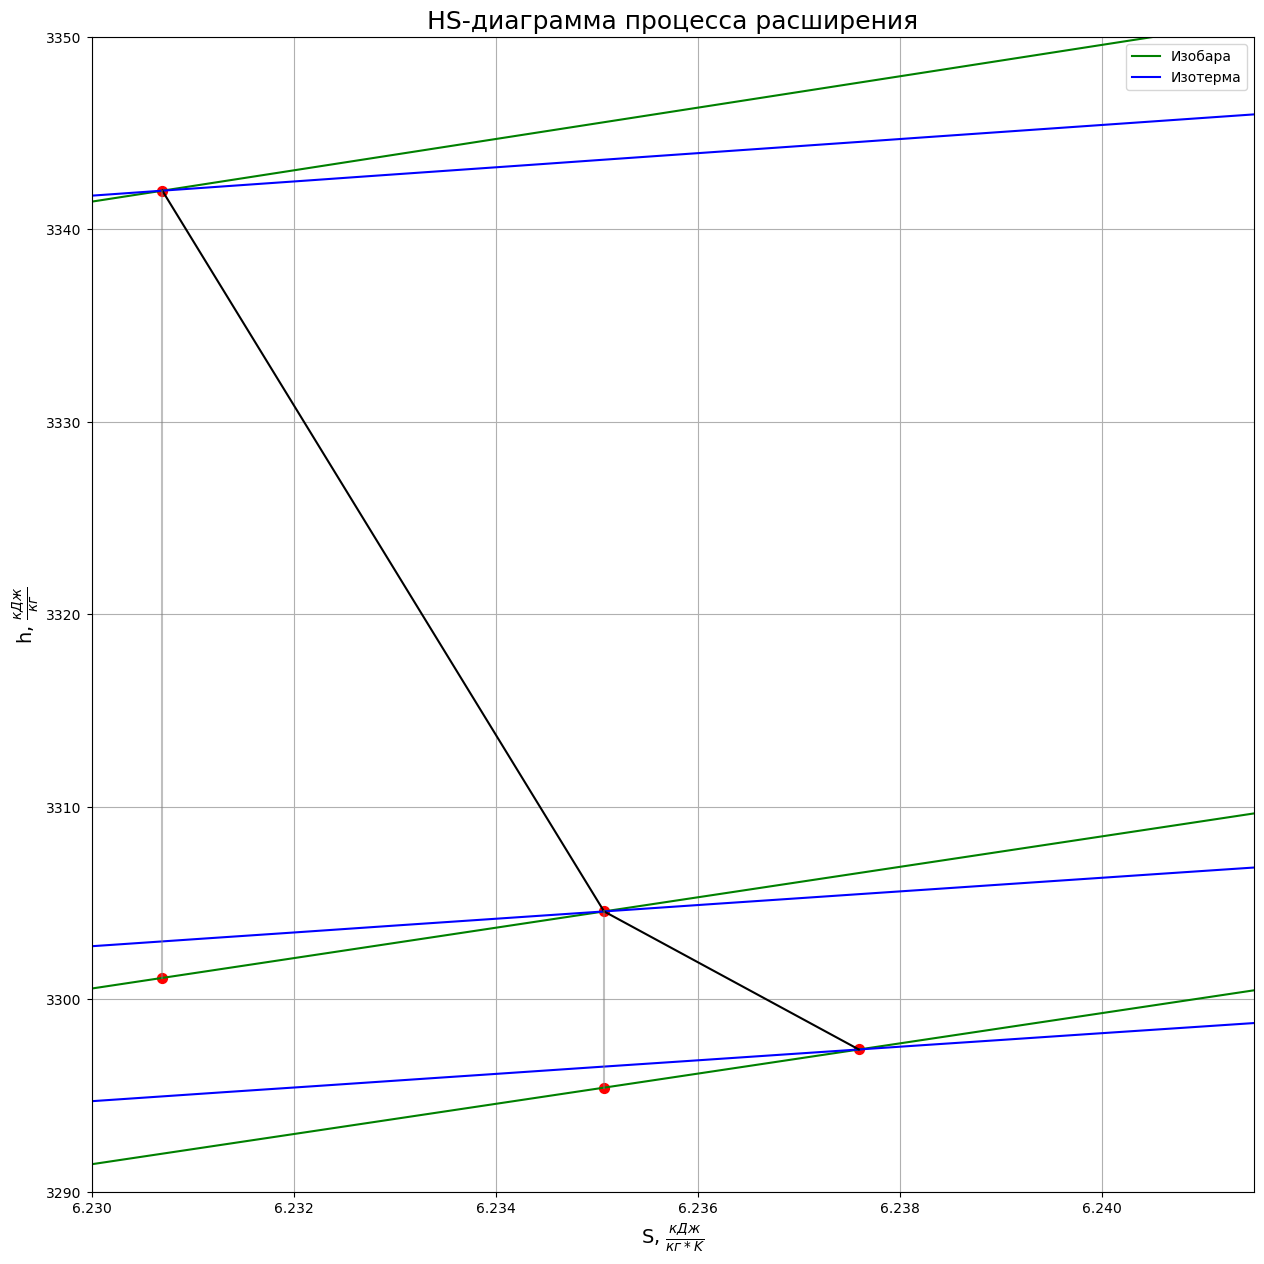

In [10]:
H_o = new_actual_heat_drop_my
k = 1.33
n = 60
rho = reaction_degree_my
b_1 = 150
d_r = diameter_my
p0 = p_in * MPa
t0 = T_in
alpha_1_e = 13
t_1opt = (0.7+0.87)/2
t_opt_2 = (0.60+0.70)/2
b_2 = 20
G = inlet_mass_flow = 257.13
pere = overlapping
xi_vs = 0
W_min_atlas = 0.575

eff_ol_energy, eff_ol_angle, eff_oi, u_cf, velocity_df, loss_df, thermodynamic_df = A.my_blade(H_o, p0,t0, k, n, rho, b_1, alpha_1_e, t_1opt, t_opt_2, b_2, G, pere, xi_vs, d_r, W_min_atlas, blade_length_my)

In [11]:
loss_df

,"Потери, %"
Тип потерь,
В сопловой решетке,6.902
В рабочей решетке,3.963
Энергия выходной скорости,0.636
Потери от утечек через уплотнение,8.354
Потери от трения диска,0.533
Потери от парциальности,5.220


In [12]:
thermodynamic_df

,"Давление (P), МПа","Температура (T), K","Энтальпия (h), кДж/кг","Энтропия (s), кДж/(кг·K)"
Состояние,,,,
Параметры перед ступенью,22.230,540.605,3342.009,6.231
Теоретические параметры за сопловой решеткой,19.518,516.678,3301.114,6.231
Фактические параметры за сопловой решеткой,19.518,517.789,3304.568,6.235
Теоретические параметры за ступенью,18.949,512.432,3295.413,6.235
Фактические параметры за ступенью,18.949,513.072,3297.397,6.238


In [ ]:
#eff_ol_energy, eff_ol_angle, eff_oi, u_cf, velocity_df, loss_df, thermodynamic_df = A.efficiency_oi_ol (H_o, p0,t0, k, n, rho, b_1, alpha_1_e, t_1opt, t_opt_2, b_2, G, pere, xi_vs, d_r[i], W_min_atlas)